# Classification Problem

A classification problem is a type of supervised machine learning task where the goal is to predict the categorical label (class) of an input based on its features. The output variable is a category or class, and the task is to classify the input data into one of these predefined classes.

*   Binary Classification: There are only two possible classes (e.g., "Yes" vs. "No," "True" vs. "False").
*   Multiclass Classification: There are more than two classes, and each input is assigned to one of these classes (e.g., classifying flowers into "Setosa," "Versicolor," "Virginica").
*   Multilabel Classification: Each input can belong to multiple classes at the same time (e.g., a movie could belong to both "Action" and "Adventure" genres).



## Soil Analysis

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the "crop" column is the optimal choice for that field. This is a multiclass classification problem.

The goal is to predict the best crop for a farmer's field based on the soil conditions they have.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/LT_Datasets/soil_measures.csv")
df.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


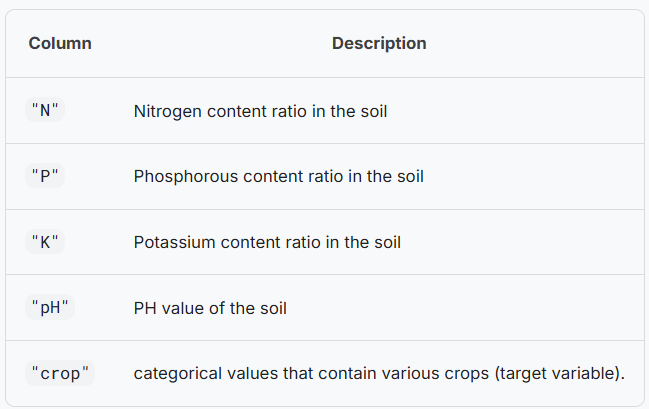

## EDA

In [ ]:
df.shape

(2200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
ph,0
crop,0


In [ ]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


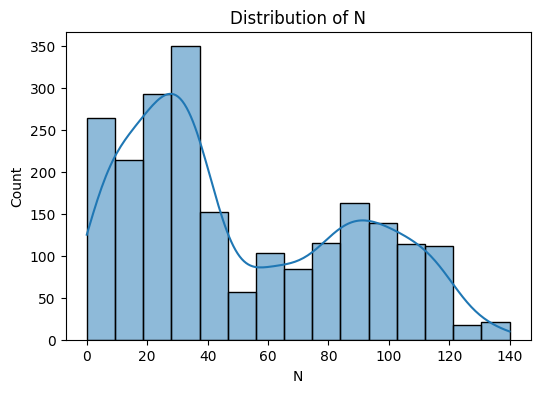

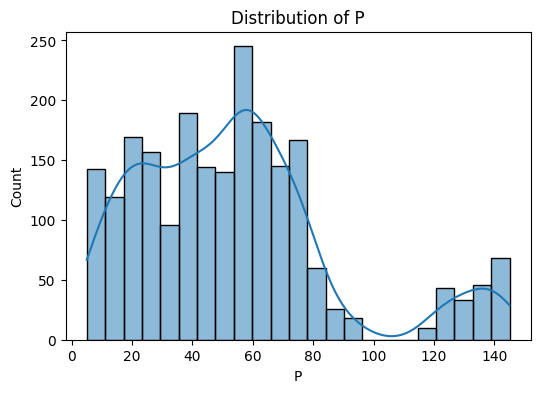

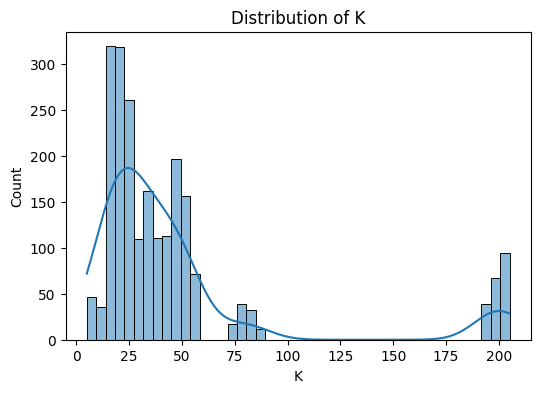

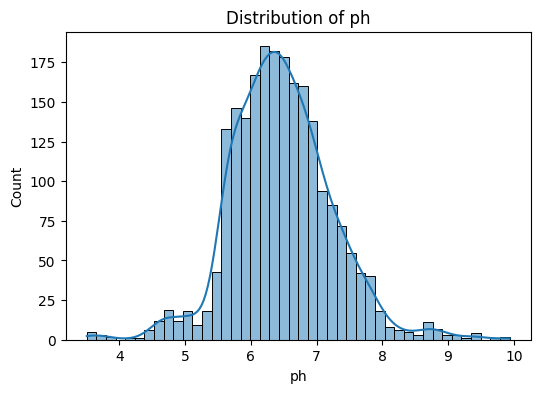

In [ ]:
num_cols = ['N', 'P', 'K', 'ph']
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

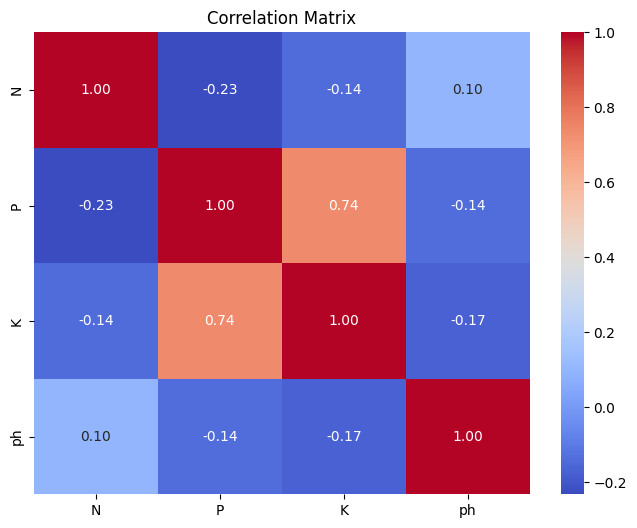

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

<ipython-input-105-079ffc9395ae>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='crop', data=df, palette="pastel")


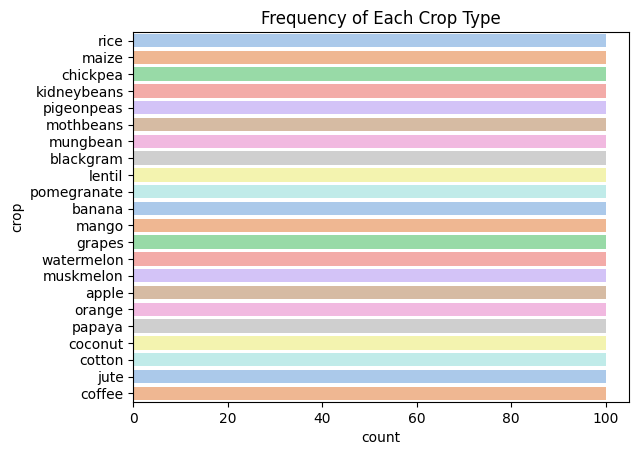

In [ ]:
sns.countplot(y='crop', data=df, palette="pastel")
plt.title("Frequency of Each Crop Type")
plt.show()

In [ ]:
df['crop'].nunique()

22

In [ ]:
df['crop'].value_counts()

,count
crop,
rice,100
maize,100
jute,100
cotton,100
coconut,100
papaya,100
orange,100
apple,100
muskmelon,100


## Splitting the dataset:-

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified Train-Test Split
X = df[['N', 'P', 'K', 'ph']]
y = df['crop']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
# Encoding the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [ ]:
# Get the class-to-encoded label mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class to Encoded Label Mapping:")
print(class_mapping)

Class to Encoded Label Mapping:
{'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5, 'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11, 'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16, 'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21}


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train = pd.DataFrame(X_train_scaled, columns=['N', 'P', 'K', 'ph'])
X_test = pd.DataFrame(X_test_scaled, columns=['N', 'P', 'K', 'ph'])
y_train = pd.Series(y_train_encoded, name='crop')
y_test = pd.Series(y_test_encoded, name='crop')

In [ ]:
X_train.head()

,N,P,K,ph
0,-1.371628,-1.072910,-0.673510,0.937545
1,-1.127411,2.084513,3.015261,-1.153846
2,-1.073140,0.536162,-0.476250,-1.107452
3,-0.340487,-0.465713,-0.594606,-0.229482
4,-0.883193,-1.255069,-0.791866,-0.341959


In [ ]:
y_train.head()

,crop
0,16
1,7
2,9
3,13
4,16


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Initialize and train logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Make predictions on the test set
y_pred = logreg.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.6818181818181818


In [ ]:
# Classification report for more detailed performance metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        20
           1       0.95      1.00      0.98        20
           2       0.60      0.75      0.67        20
           3       1.00      0.90      0.95        20
           4       0.71      0.60      0.65        20
           5       0.90      0.95      0.93        20
           6       0.90      0.95      0.93        20
           7       0.56      0.50      0.53        20
           8       0.59      0.50      0.54        20
           9       0.46      0.60      0.52        20
          10       0.58      0.55      0.56        20
          11       1.00      0.95      0.97        20
          12       0.55      0.55      0.55        20
          13       0.41      0.35      0.38        20
          14       0.71      0.60      0.65        20
          15       0.50      0.50      0.50        20
          16       0.95      1.00      0.98        20
   

In [ ]:
# Confusion matrix to see prediction breakdown
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[12  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 15  0  0  0  0  0  0  0  3  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0]
 [ 0  0  0  0 12  0  0  0  0  0  0  0  5  0  0  0  0  0  0  3  0  0]
 [ 0  0  0  0  0 19  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [10  0  0  0  0  0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0 10  0  0  0  0  0  0  0  0  0  0  0  9  0]
 [ 0  0  0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  8  0  0  0]
 [ 0  0  5  0  0  0  0  0  0  0 11  0  0  1  1  0  0  0  2  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0 11  1  0  0  1  0  0  3  0  0]
 [ 0  0  2  0  0  0  0  0  0  5  0  0  2  7  4  0  0  0  0  0  0  0]
 [ 0  0  2  0  


AUC Score (One-vs-Rest): 0.9796103896103894


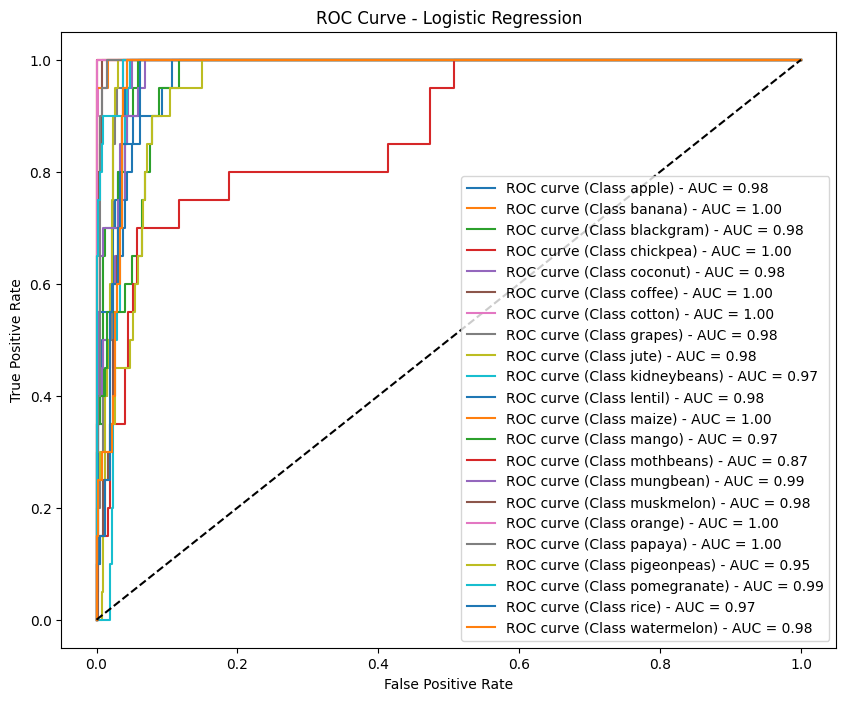

In [ ]:
# ROC and AUC Score
# For multi-class classification, we use a One-vs-Rest (OvR) approach to calculate ROC

# This is a multi-class problem, we need to use predict_proba and OvR
y_pred_proba = logreg.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")

print(f"\nAUC Score (One-vs-Rest): {roc_auc}")

# Plotting ROC Curve for each class
fpr = {}
tpr = {}
roc_auc = {}

# For each class, calculate FPR, TPR, and AUC
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"ROC curve (Class {label_encoder.classes_[i]}) - AUC = {roc_auc[i]:.2f}")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

## K-NN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize K-NN model (you can tune n_neighbors)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the K-NN model on the training data
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# 3. Make predictions on the test set
y_pred_knn = knn.predict(X_test)

In [ ]:
# 4. Evaluate the K-NN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Test Accuracy (K-NN):", accuracy_knn)

# Classification report for more detailed performance metrics
print("\nClassification Report (K-NN):")
print(classification_report(y_test, y_pred_knn))

# Confusion matrix to see prediction breakdown
print("\nConfusion Matrix (K-NN):")
print(confusion_matrix(y_test, y_pred_knn))

Test Accuracy (K-NN): 0.7045454545454546

Classification Report (K-NN):
              precision    recall  f1-score   support

           0       0.48      0.55      0.51        20
           1       1.00      1.00      1.00        20
           2       0.60      0.75      0.67        20
           3       1.00      1.00      1.00        20
           4       0.53      0.80      0.64        20
           5       0.91      1.00      0.95        20
           6       0.83      1.00      0.91        20
           7       0.47      0.40      0.43        20
           8       0.65      0.55      0.59        20
           9       0.74      0.85      0.79        20
          10       0.44      0.40      0.42        20
          11       0.88      0.75      0.81        20
          12       0.71      0.60      0.65        20
          13       0.90      0.45      0.60        20
          14       0.78      0.90      0.84        20
          15       0.50      0.55      0.52        20
         

K-NN with Hyperparameter Tuning :-

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Define hyperparameters grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],  # Range of neighbors to test
    'weights': ['uniform', 'distance'],   # Weights function
    'metric': ['euclidean', 'manhattan']  # Distance metric
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model with training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")


Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


In [ ]:
# Make predictions with the best model
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

In [ ]:
# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Test Accuracy (K-NN with Hyperparameter Tuning):", accuracy_knn)

# Classification report for more detailed performance metrics
print("\nClassification Report (K-NN with Hyperparameter Tuning):")
print(classification_report(y_test, y_pred_knn))

# Confusion matrix to see prediction breakdown
print("\nConfusion Matrix (K-NN with Hyperparameter Tuning):")
print(confusion_matrix(y_test, y_pred_knn))

Test Accuracy (K-NN with Hyperparameter Tuning): 0.725

Classification Report (K-NN with Hyperparameter Tuning):
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        20
           1       1.00      1.00      1.00        20
           2       0.63      0.85      0.72        20
           3       1.00      1.00      1.00        20
           4       0.59      0.80      0.68        20
           5       0.91      1.00      0.95        20
           6       0.87      1.00      0.93        20
           7       0.50      0.40      0.44        20
           8       0.63      0.60      0.62        20
           9       0.74      1.00      0.85        20
          10       0.47      0.40      0.43        20
          11       0.94      0.75      0.83        20
          12       0.81      0.65      0.72        20
          13       0.93      0.65      0.76        20
          14       0.90      0.95      0.93        20
          15       0.3


AUC Score (One-vs-Rest): 0.9830221861471863


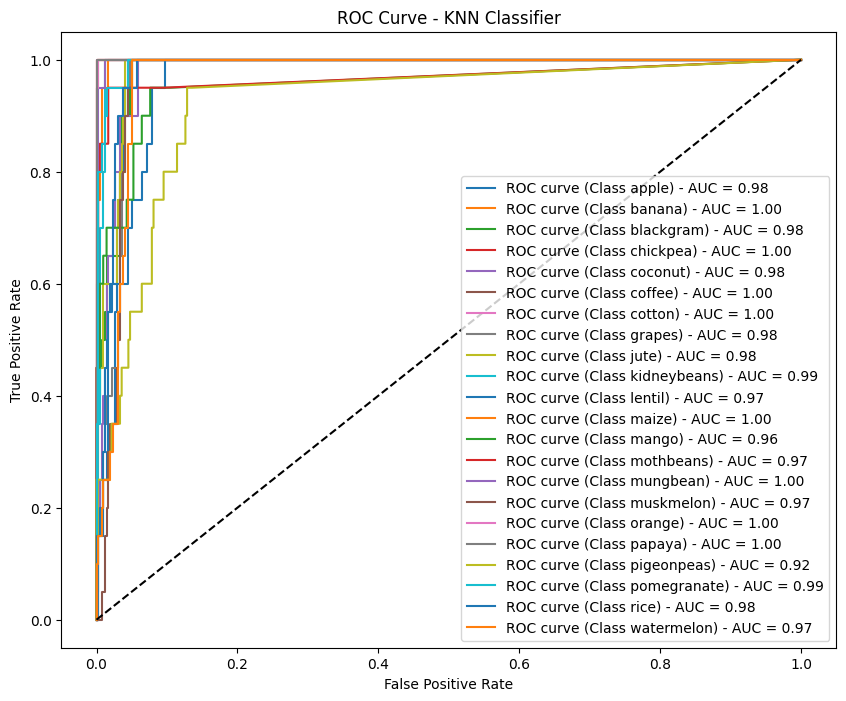

In [ ]:
# ROC and AUC Score
# For multi-class classification, we use a One-vs-Rest (OvR) approach to calculate ROC

# This is a multi-class problem, we need to use predict_proba and OvR
y_pred_proba = best_knn.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")

print(f"\nAUC Score (One-vs-Rest): {roc_auc}")

# Plotting ROC Curve for each class
fpr = {}
tpr = {}
roc_auc = {}

# For each class, calculate FPR, TPR, and AUC
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"ROC curve (Class {label_encoder.classes_[i]}) - AUC = {roc_auc[i]:.2f}")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Classifier")
plt.legend(loc="lower right")
plt.show()

## Support Vector Classifier

In [ ]:
from sklearn.svm import SVC

In [ ]:
# Initialize Support Vector Classifier (you can choose different kernels)
svc = SVC(kernel='linear')  # You can also use 'rbf', 'poly', etc.

# Train the SVC model on the training data
svc.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_svc = svc.predict(X_test)

In [ ]:
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("Test Accuracy (SVC):", accuracy_svc)

print("\nClassification Report (SVC):")
print(classification_report(y_test, y_pred_svc))

print("\nConfusion Matrix (SVC):")
print(confusion_matrix(y_test, y_pred_svc))

Test Accuracy (SVC): 0.7090909090909091

Classification Report (SVC):
              precision    recall  f1-score   support

           0       0.52      0.55      0.54        20
           1       1.00      1.00      1.00        20
           2       0.62      0.75      0.68        20
           3       1.00      1.00      1.00        20
           4       0.68      0.65      0.67        20
           5       0.91      1.00      0.95        20
           6       0.95      0.95      0.95        20
           7       0.53      0.50      0.51        20
           8       0.58      0.55      0.56        20
           9       0.45      1.00      0.62        20
          10       0.50      0.60      0.55        20
          11       1.00      0.90      0.95        20
          12       0.52      0.60      0.56        20
          13       1.00      0.20      0.33        20
          14       0.82      0.90      0.86        20
          15       0.48      0.50      0.49        20
          1

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVC with HyperParameter Tuning:-

In [ ]:
svc = SVC()

# Define the hyperparameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],               # Range of C values
    'kernel': ['linear', 'rbf', 'poly'],   # Different kernel types
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]  # Gamma values
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model with training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

Best Hyperparameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# Make predictions with the best model
best_svc = grid_search.best_estimator_
y_pred_svc = best_svc.predict(X_test)

In [ ]:
# Evaluate the model
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print("Test Accuracy (SVC with Hyperparameter Tuning):", accuracy_svc)

# Classification report for more detailed performance metrics
print("\nClassification Report (SVC with Hyperparameter Tuning):")
print(classification_report(y_test, y_pred_svc))

# Confusion matrix to see prediction breakdown
print("\nConfusion Matrix (SVC with Hyperparameter Tuning):")
print(confusion_matrix(y_test, y_pred_svc))


Test Accuracy (SVC with Hyperparameter Tuning): 0.7840909090909091

Classification Report (SVC with Hyperparameter Tuning):
              precision    recall  f1-score   support

           0       0.54      0.65      0.59        20
           1       1.00      1.00      1.00        20
           2       0.57      0.85      0.68        20
           3       1.00      1.00      1.00        20
           4       0.73      0.95      0.83        20
           5       1.00      1.00      1.00        20
           6       0.91      1.00      0.95        20
           7       0.56      0.45      0.50        20
           8       0.68      0.85      0.76        20
           9       0.77      1.00      0.87        20
          10       0.68      0.65      0.67        20
          11       1.00      0.90      0.95        20
          12       0.88      0.70      0.78        20
          13       0.94      0.75      0.83        20
          14       0.82      0.90      0.86        20
          1

## Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],                 # Various tree depths
    'min_samples_split': [2, 10, 20, 30],                   # Minimum samples needed to split a node
    'min_samples_leaf': [1, 5, 10, 20],                     # Minimum samples required at a leaf node
    'max_features': ['auto', 'sqrt', 'log2', None],         # Number of features to consider for best split
    'criterion': ['gini', 'entropy']                        # Split quality metric
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model with training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
960 fits failed out of a total of 3840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [ ]:
best_dtc = grid_search.best_estimator_
y_pred_dtc = best_dtc.predict(X_test)

Note:-

 best_params_ and best_estimator_ both refer to the results from a grid search, but they serve different purposes:

*   best_params_: This is a dictionary that contains the best combination of hyperparameters found during the grid search. It gives only the values of the hyperparameters that produced the best score.
*   best_estimator_: This is the actual model object (an estimator) that was trained using the best combination of hyperparameters from the grid search. You can use best_estimator_ to directly make predictions, evaluate performance, or further analyze the model, as it is a fully trained instance.



In [ ]:
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print("Test Accuracy (Decision Tree with Hyperparameter Tuning):", accuracy_dtc)

print("\nClassification Report (Decision Tree with Hyperparameter Tuning):")
print(classification_report(y_test, y_pred_dtc))

print("\nConfusion Matrix (Decision Tree with Hyperparameter Tuning):")
print(confusion_matrix(y_test, y_pred_dtc))

Test Accuracy (Decision Tree with Hyperparameter Tuning): 0.7681818181818182

Classification Report (Decision Tree with Hyperparameter Tuning):
              precision    recall  f1-score   support

           0       0.37      0.35      0.36        20
           1       1.00      1.00      1.00        20
           2       0.59      0.85      0.69        20
           3       1.00      1.00      1.00        20
           4       0.72      0.90      0.80        20
           5       1.00      0.90      0.95        20
           6       1.00      1.00      1.00        20
           7       0.38      0.40      0.39        20
           8       0.60      0.90      0.72        20
           9       0.80      1.00      0.89        20
          10       0.47      0.35      0.40        20
          11       0.91      1.00      0.95        20
          12       0.87      0.65      0.74        20
          13       0.94      0.85      0.89        20
          14       0.83      0.95      0.88  


AUC Score (One-vs-Rest): 0.9530032467532469


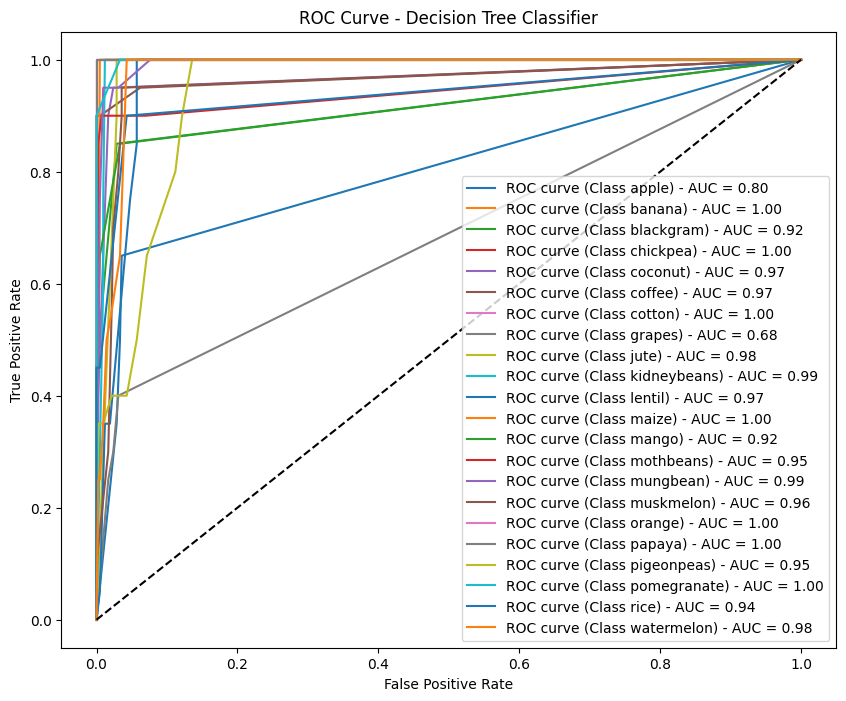

In [ ]:
# ROC and AUC Score
# For multi-class classification, we use a One-vs-Rest (OvR) approach to calculate ROC

# If this is a multi-class problem, we need to use predict_proba and OvR
y_pred_proba = best_dtc.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")

print(f"\nAUC Score (One-vs-Rest): {roc_auc}")

# Plotting ROC Curve for each class
fpr = {}
tpr = {}
roc_auc = {}

# For each class, calculate FPR, TPR, and AUC
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"ROC curve (Class {label_encoder.classes_[i]}) - AUC = {roc_auc[i]:.2f}")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend(loc="lower right")
plt.show()

## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],                 # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],                # Max depth of each tree
    'min_samples_split': [2, 10, 20],               # Minimum samples to split an internal node
    'min_samples_leaf': [1, 5, 10],                 # Minimum samples to be at a leaf node
    'max_features': ['auto', 'sqrt', 'log2'],       # Number of features for the best split
    'criterion': ['gini', 'entropy']                # Quality measure for a split
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model with training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters from the grid search
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1080 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/u

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# Make predictions with the best model
best_rfc = grid_search.best_estimator_
y_pred_rfc = best_rfc.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Evaluate Accuracy
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
print("Test Accuracy (Random Forest with Hyperparameter Tuning):", accuracy_rfc)

# Classification Report (Precision, Recall, F1-score for each class)
print("\nClassification Report (Random Forest with Hyperparameter Tuning):")
print(classification_report(y_test, y_pred_rfc))

# Confusion Matrix
print("\nConfusion Matrix (Random Forest with Hyperparameter Tuning):")
conf_matrix = confusion_matrix(y_test, y_pred_rfc)
print(conf_matrix)

Test Accuracy (Random Forest with Hyperparameter Tuning): 0.7840909090909091

Classification Report (Random Forest with Hyperparameter Tuning):
              precision    recall  f1-score   support

           0       0.48      0.50      0.49        20
           1       1.00      1.00      1.00        20
           2       0.61      0.85      0.71        20
           3       1.00      1.00      1.00        20
           4       0.73      0.95      0.83        20
           5       1.00      0.95      0.97        20
           6       1.00      1.00      1.00        20
           7       0.47      0.45      0.46        20
           8       0.68      0.95      0.79        20
           9       0.80      1.00      0.89        20
          10       0.60      0.45      0.51        20
          11       0.95      1.00      0.98        20
          12       0.93      0.65      0.76        20
          13       0.85      0.85      0.85        20
          14       0.83      0.95      0.88  


AUC Score (One-vs-Rest): 0.989112554112554


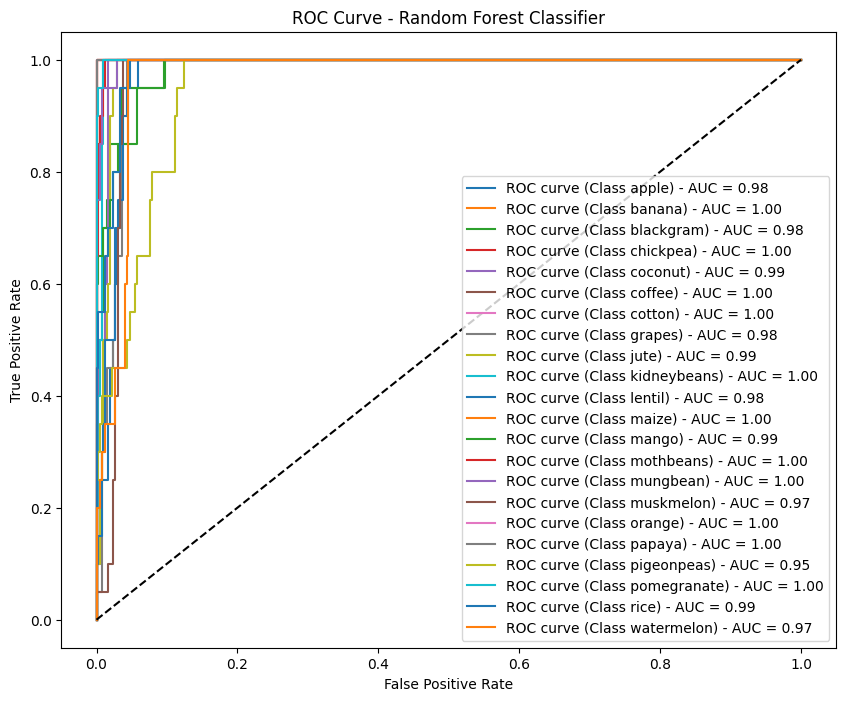

In [ ]:
# ROC and AUC Score
# For multi-class classification, we use a One-vs-Rest (OvR) approach to calculate ROC

# If this is a multi-class problem, we need to use predict_proba and OvR
y_pred_proba = best_rfc.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr")

print(f"\nAUC Score (One-vs-Rest): {roc_auc}")

# 6. Plotting ROC Curve for each class
fpr = {}
tpr = {}
roc_auc = {}

# For each class, calculate FPR, TPR, and AUC
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"ROC curve (Class {label_encoder.classes_[i]}) - AUC = {roc_auc[i]:.2f}")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.show()

In [ ]:
accuracies = {
    "Logistic Regression": accuracy,
    "K-Nearest Neighbors": accuracy_knn,
    "Support Vector Classifier": accuracy_svc,
    "Decision Tree": accuracy_dtc,
    "Random Forest": accuracy_rfc
}

# Display the accuracies
for model, acc in accuracies.items():
    print(f"{model}: {acc:.4f}")

# SVC and Random Forest are best classifiers for this problem

Logistic Regression: 0.6818
K-Nearest Neighbors: 0.7250
Support Vector Classifier: 0.7841
Decision Tree: 0.7682
Random Forest: 0.7841


## Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(random_state=42)

# 2. Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=gb_clf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best hyperparameters
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50}


In [ ]:
best_gb_clf = grid_search.best_estimator_
y_pred = best_gb_clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy_gb = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_gb}")

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()